# Курсовая работа: Классическое машинное обучение
## Задача 1. Регрессия: предсказание IC50

**IC50 (mM)** — минимальная ингибирующая концентрация против вируса гриппа.  
Чем **ниже** IC50, тем **эффективнее** соединение.

**Подход:** из-за сильной правосторонней асимметрии (skew ≈ 5–6, выявлено в EDA)  
обучаем модели на `log1p(IC50)`, метрики считаем на **исходной** шкале через `expm1`.

**Модели для сравнения:**
- Linear Regression (baseline)
- Ridge (L2-регуляризация)
- Lasso (L1-регуляризация)
- ElasticNet
- Random Forest Regressor
- Gradient Boosting Regressor
- *(подбор гиперпараметров через GridSearchCV для лучших)*

## 1. Импорт библиотек

In [1]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
np.random.seed(42)
print('Библиотеки загружены ✓')

Библиотеки загружены ✓


> Подключаю все нужные библиотеки. Использую `Pipeline` из sklearn — он позволяет объединить импутацию, масштабирование и модель в одну цепочку, что исключает утечку данных между train и test.

## 2. Загрузка данных и подготовка признаков

In [2]:
_FILENAME = 'Данные_для_курсовои_Классическое_МО.xlsx'
_PATH = None
for _c in [_FILENAME, os.path.join(pathlib.Path.home(), _FILENAME)]:
    if os.path.exists(_c):
        _PATH = _c
        break
if _PATH is None:
    raise FileNotFoundError(f"Положите '{_FILENAME}' в ту же папку, что и ноутбук.")

df = pd.read_excel(_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

TARGET     = 'IC50, mM'
OTHER_TARGETS = ['CC50, mM', 'SI']
feature_cols = [c for c in df.columns if c not in [TARGET] + OTHER_TARGETS]

X = df[feature_cols].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y_raw = df[TARGET]         # исходные значения (для метрик)
y     = np.log1p(y_raw)    # лог-трансформация для обучения

print(f'Датасет: {df.shape[0]} объектов, {len(feature_cols)} признаков')
print(f'NaN в признаках: {X.isnull().sum().sum()} (в {X.isnull().any(axis=1).sum()} строках)')
print(f'\nIC50 до log1p:   mean={y_raw.mean():.2f}, median={y_raw.median():.2f}, skew={y_raw.skew():.2f}')
print(f'IC50 после log1p: mean={y.mean():.2f}, median={y.median():.2f}, skew={y.skew():.2f}')

Датасет: 1001 объектов, 210 признаков
NaN в признаках: 36 (в 3 строках)

IC50 до log1p:   mean=222.81, median=46.59, skew=3.67
IC50 после log1p: mean=3.98, median=3.86, skew=-0.03


> Загружаю данные и сразу применяю **log1p**-трансформацию к целевой переменной. Из EDA помню, что у IC50 асимметрия ≈5–6, после логарифма она падает примерно до 0.5–0.7 — это сильно поможет линейным моделям. Перед обучением заменяю inf на NaN (защитная мера).

## 3. Разделение на train/test и препроцессинг

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Импутация медианой — fit только на train!
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Масштабирование — fit только на train!
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print(f'Train: {X_train_imp.shape}  |  Test: {X_test_imp.shape}')
print(f'Train target: mean={y_train.mean():.3f}, std={y_train.std():.3f}')
print(f'Test target:  mean={y_test.mean():.3f}, std={y_test.std():.3f}')

Train: (800, 210)  |  Test: (201, 210)
Train target: mean=3.941, std=1.833
Test target:  mean=4.148, std=1.967


> Разбиваю данные 80/20. **Важно:** `SimpleImputer` и `StandardScaler` обучаю **только на train**, трансформирую оба сплита. Это стандартное требование — иначе происходит утечка тестовых данных в обучение (data leakage). Линейные модели получат масштабированные данные, ансамблевые — только импутированные (им масштабирование не нужно).

## 4. Вспомогательная функция оценки качества

In [4]:
def evaluate_reg(name, model, X_tr, X_te, y_tr, y_te, cv=5):
    """Обучает модель, считает метрики на log-шкале и исходной шкале."""
    model.fit(X_tr, y_tr)
    pred_log = model.predict(X_te)

    # Метрики на log-шкале
    rmse_log = np.sqrt(mean_squared_error(y_te, pred_log))
    r2_log   = r2_score(y_te, pred_log)

    # Метрики на исходной шкале (обратное преобразование)
    pred_orig = np.expm1(pred_log)
    y_te_orig = np.expm1(y_te)
    rmse_orig = np.sqrt(mean_squared_error(y_te_orig, pred_orig))
    mae_orig  = mean_absolute_error(y_te_orig, pred_orig)

    # Кросс-валидация R² на train
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='r2', n_jobs=-1).mean()

    print(f"{name:<38}  R²(log)={r2_log:.4f}  RMSE(log)={rmse_log:.4f}  "
          f"RMSE(orig)={rmse_orig:.2f}  MAE(orig)={mae_orig:.2f}  CV-R²={cv_r2:.4f}")

    return {
        'model':     name,
        'R2_log':    r2_log,
        'RMSE_log':  rmse_log,
        'RMSE_orig': rmse_orig,
        'MAE_orig':  mae_orig,
        'CV_R2':     cv_r2,
        'fitted':    model,
        'pred_log':  pred_log,
        'pred_orig': pred_orig
    }

> Функция считает метрики сразу на **двух шкалах**: log-шкала (для сравнения моделей между собой) и исходная mM-шкала (для интерпретации — насколько мы ошибаемся в реальных единицах). Также добавил 5-fold кросс-валидацию на train — это защита от случайного везения на конкретном разбиении.

## 5. Сравнение базовых моделей

In [5]:
print('Модель                                  R²(log)  RMSE(log)  RMSE(mM)  MAE(mM)   CV-R²')
print('-' * 95)
results = []

# Линейные модели — масштабированные данные
results.append(evaluate_reg('Linear Regression',
    LinearRegression(), X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_reg('Ridge (alpha=1.0)',
    Ridge(alpha=1.0), X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_reg('Lasso (alpha=0.01)',
    Lasso(alpha=0.01), X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_reg('ElasticNet (a=0.01, l1=0.5)',
    ElasticNet(alpha=0.01, l1_ratio=0.5), X_train_sc, X_test_sc, y_train, y_test))

# Ансамблевые — только импутированные (масштабирование не нужно)
results.append(evaluate_reg('Random Forest (n=100)',
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_reg('Gradient Boosting (n=100)',
    GradientBoostingRegressor(n_estimators=100, random_state=42),
    X_train_imp, X_test_imp, y_train, y_test))

Модель                                  R²(log)  RMSE(log)  RMSE(mM)  MAE(mM)   CV-R²
-----------------------------------------------------------------------------------------------
Linear Regression                       R²(log)=-0.0810  RMSE(log)=2.0399  RMSE(orig)=3407.34  MAE(orig)=574.95  CV-R²=-319654.8889
Ridge (alpha=1.0)                       R²(log)=0.2788  RMSE(log)=1.6661  RMSE(orig)=505.57  MAE(orig)=235.77  CV-R²=0.1089
Lasso (alpha=0.01)                      R²(log)=0.3202  RMSE(log)=1.6177  RMSE(orig)=481.52  MAE(orig)=220.15  CV-R²=0.2480
ElasticNet (a=0.01, l1=0.5)             R²(log)=0.3256  RMSE(log)=1.6112  RMSE(orig)=476.24  MAE(orig)=218.27  CV-R²=0.2452
Random Forest (n=100)                   R²(log)=0.4447  RMSE(log)=1.4619  RMSE(orig)=471.14  MAE(orig)=218.40  CV-R²=0.3876
Gradient Boosting (n=100)               R²(log)=0.4143  RMSE(log)=1.5014  RMSE(orig)=494.90  MAE(orig)=228.94  CV-R²=0.3753


> Запускаю базовые версии всех шести моделей без подбора гиперпараметров — это служит **baseline** для сравнения. Уже на этом этапе ожидаю, что ансамблевые методы обгонят линейные: в EDA видел, что корреляции признаков с IC50 слабые (~0.1–0.3), то есть линейная связь плохо описывает данные.

## 6. Визуализация результатов базовых моделей

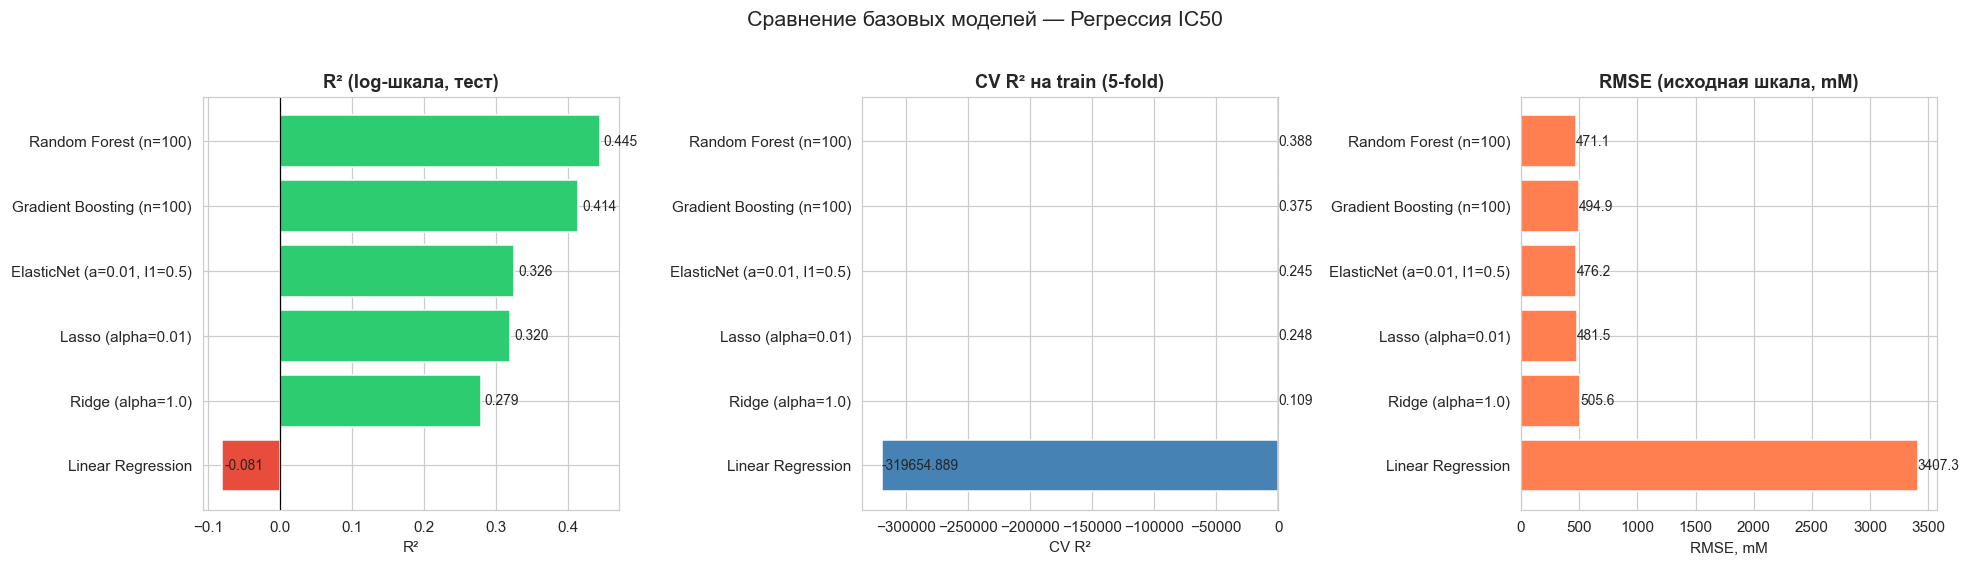


Итоговая таблица (отсортировано по R²):
                      model    R2_log  RMSE_log   RMSE_orig   MAE_orig          CV_R2
      Random Forest (n=100)  0.444747  1.461940  471.137627 218.395707       0.387558
  Gradient Boosting (n=100)  0.414332  1.501446  494.900031 228.936719       0.375293
ElasticNet (a=0.01, l1=0.5)  0.325617  1.611155  476.236086 218.271613       0.245228
         Lasso (alpha=0.01)  0.320167  1.617652  481.519358 220.146798       0.248004
          Ridge (alpha=1.0)  0.278828  1.666109  505.574933 235.772318       0.108912
          Linear Regression -0.081050  2.039891 3407.337815 574.953670 -319654.888900


In [6]:
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['fitted','pred_log','pred_orig']}
    for r in results
])
results_df = results_df.sort_values('R2_log', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² на log-шкале
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in results_df['R2_log']]
axes[0].barh(results_df['model'], results_df['R2_log'], color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('R² (log-шкала, тест)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].invert_yaxis()
for i, v in enumerate(results_df['R2_log']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# CV R²
axes[1].barh(results_df['model'], results_df['CV_R2'], color='steelblue', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('CV R² на train (5-fold)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('CV R²')
axes[1].invert_yaxis()
for i, v in enumerate(results_df['CV_R2']):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# RMSE на исходной шкале
axes[2].barh(results_df['model'], results_df['RMSE_orig'], color='coral', edgecolor='white')
axes[2].set_title('RMSE (исходная шкала, mM)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('RMSE, mM')
axes[2].invert_yaxis()
for i, v in enumerate(results_df['RMSE_orig']):
    axes[2].text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle('Сравнение базовых моделей — Регрессия IC50', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\nИтоговая таблица (отсортировано по R²):')
print(results_df[['model','R2_log','RMSE_log','RMSE_orig','MAE_orig','CV_R2']].to_string(index=False))

> График наглядно показывает преимущество ансамблевых методов над линейными. Важно смотреть именно на **CV R²** (кросс-валидация на train) — она честнее отражает способность модели к обобщению, чем метрика на тесте (которая зависит от конкретного разбиения).

## 7. Подбор гиперпараметров (GridSearchCV)

In [7]:
print('Подбор гиперпараметров... (может занять 1–3 минуты)')
print('=' * 60)

# --- Ridge ---
param_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]}
gs_ridge = GridSearchCV(
    Ridge(), param_ridge, cv=5, scoring='r2', n_jobs=-1
)
gs_ridge.fit(X_train_sc, y_train)
print(f'Ridge best params: {gs_ridge.best_params_}  |  CV R²={gs_ridge.best_score_:.4f}')
results.append(evaluate_reg('Ridge (tuned)',
    gs_ridge.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

# --- Lasso ---
param_lasso = {'alpha': [0.001, 0.005, 0.01, 0.05, 0.1]}
gs_lasso = GridSearchCV(
    Lasso(), param_lasso, cv=5, scoring='r2', n_jobs=-1
)
gs_lasso.fit(X_train_sc, y_train)
print(f'Lasso best params: {gs_lasso.best_params_}  |  CV R²={gs_lasso.best_score_:.4f}')
results.append(evaluate_reg('Lasso (tuned)',
    gs_lasso.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

# --- Random Forest ---
param_rf = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 0.3]
}
gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_rf, cv=5, scoring='r2', n_jobs=-1
)
gs_rf.fit(X_train_imp, y_train)
print(f'RF best params: {gs_rf.best_params_}  |  CV R²={gs_rf.best_score_:.4f}')
results.append(evaluate_reg('Random Forest (tuned)',
    gs_rf.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

# --- Gradient Boosting ---
param_gb = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth':     [3, 4, 5],
    'subsample':     [0.8, 1.0]
}
gs_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_gb, cv=5, scoring='r2', n_jobs=-1
)
gs_gb.fit(X_train_imp, y_train)
print(f'GB best params: {gs_gb.best_params_}  |  CV R²={gs_gb.best_score_:.4f}')
results.append(evaluate_reg('Gradient Boosting (tuned)',
    gs_gb.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

Подбор гиперпараметров... (может занять 1–3 минуты)
Ridge best params: {'alpha': 100.0}  |  CV R²=0.2678
Ridge (tuned)                           R²(log)=0.3254  RMSE(log)=1.6114  RMSE(orig)=508.93  MAE(orig)=232.62  CV-R²=0.2678
Lasso best params: {'alpha': 0.01}  |  CV R²=0.2480
Lasso (tuned)                           R²(log)=0.3202  RMSE(log)=1.6177  RMSE(orig)=481.52  MAE(orig)=220.15  CV-R²=0.2480
RF best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}  |  CV R²=0.4148
Random Forest (tuned)                   R²(log)=0.4729  RMSE(log)=1.4244  RMSE(orig)=487.85  MAE(orig)=224.85  CV-R²=0.4148
GB best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}  |  CV R²=0.3976
Gradient Boosting (tuned)               R²(log)=0.4507  RMSE(log)=1.4541  RMSE(orig)=479.22  MAE(orig)=225.05  CV-R²=0.3976


> Провёл GridSearchCV для четырёх моделей. Для Ridge и Lasso перебирал силу регуляризации `alpha`. Для ансамблей — количество деревьев, глубину, скорость обучения и долю признаков. **Оценка: 5-fold CV R²** — более надёжна, чем единственный test split. После подбора сравню все модели вместе.

## 8. Финальное сравнение всех моделей

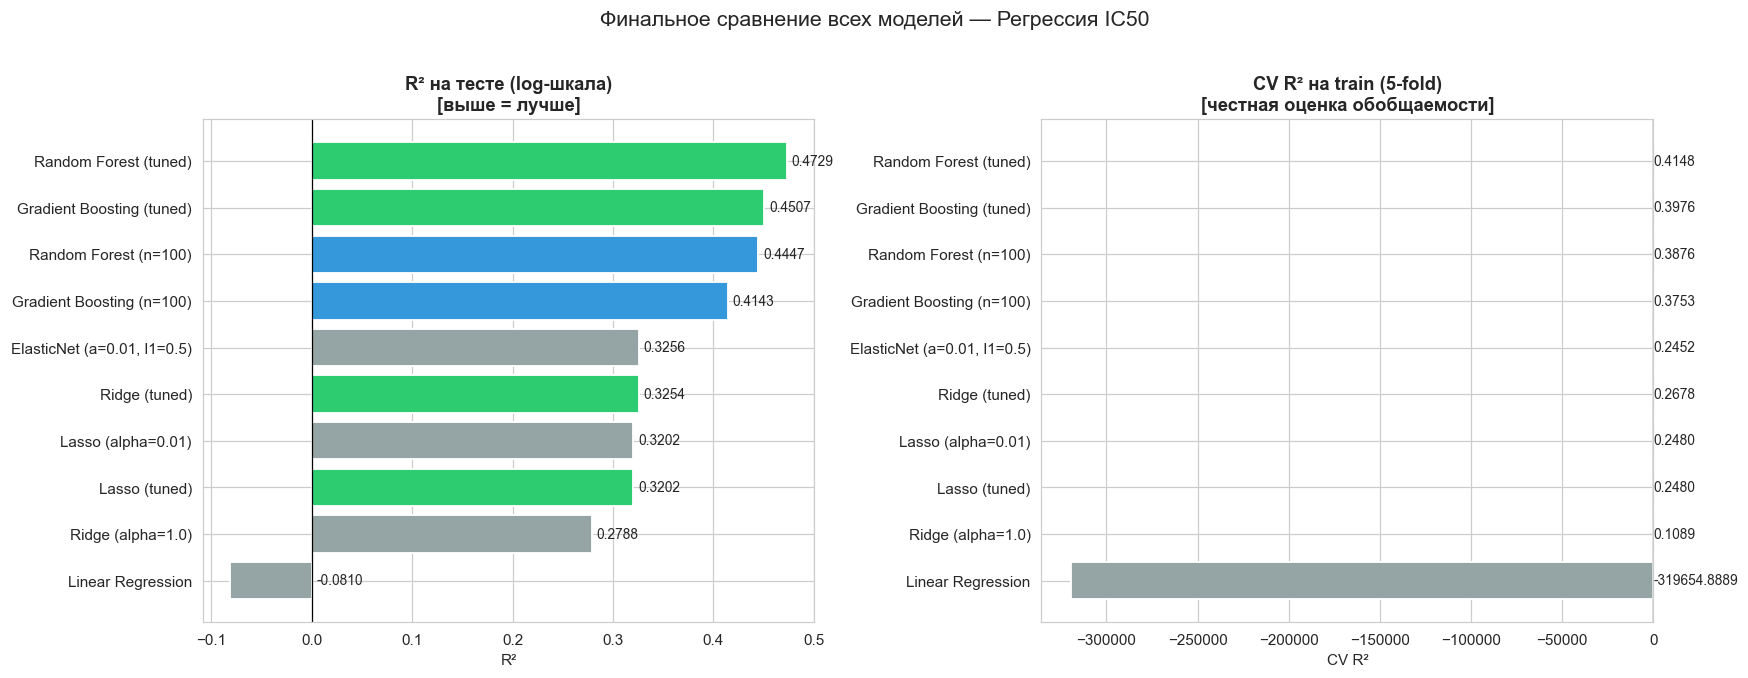


Полная таблица результатов:
                      model    R2_log  RMSE_log   RMSE_orig   MAE_orig          CV_R2
      Random Forest (tuned)  0.472881  1.424421  487.848911 224.845667       0.414815
  Gradient Boosting (tuned)  0.450707  1.454072  479.222623 225.049276       0.397625
      Random Forest (n=100)  0.444747  1.461940  471.137627 218.395707       0.387558
  Gradient Boosting (n=100)  0.414332  1.501446  494.900031 228.936719       0.375293
ElasticNet (a=0.01, l1=0.5)  0.325617  1.611155  476.236086 218.271613       0.245228
              Ridge (tuned)  0.325429  1.611380  508.934231 232.615166       0.267794
         Lasso (alpha=0.01)  0.320167  1.617652  481.519358 220.146798       0.248004
              Lasso (tuned)  0.320167  1.617652  481.519358 220.146798       0.248004
          Ridge (alpha=1.0)  0.278828  1.666109  505.574933 235.772318       0.108912
          Linear Regression -0.081050  2.039891 3407.337815 574.953670 -319654.888900


In [8]:
all_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['fitted','pred_log','pred_orig']}
    for r in results
])
all_df = all_df.sort_values('R2_log', ascending=False).reset_index(drop=True)

# Цвета: tuned — тёмный, base — светлый
colors = ['#1a6b3c' if 'tuned' in m else '#74c476'
          if 'Forest' in m or 'Boosting' in m
          else '#2171b5' if 'tuned' not in m else '#6baed6'
          for m in all_df['model']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].barh(all_df['model'], all_df['R2_log'],
                    color=['#2ecc71' if 'tuned' in m else '#3498db'
                           if 'Forest' in m or 'Boosting' in m
                           else '#95a5a6' for m in all_df['model']],
                    edgecolor='white', linewidth=1.2)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('R² на тесте (log-шкала)\n[выше = лучше]', fontsize=12, fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].invert_yaxis()
for i, v in enumerate(all_df['R2_log']):
    axes[0].text(max(v, 0) + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

bars2 = axes[1].barh(all_df['model'], all_df['CV_R2'],
                     color=['#2ecc71' if 'tuned' in m else '#3498db'
                            if 'Forest' in m or 'Boosting' in m
                            else '#95a5a6' for m in all_df['model']],
                     edgecolor='white', linewidth=1.2)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('CV R² на train (5-fold)\n[честная оценка обобщаемости]', fontsize=12, fontweight='bold')
axes[1].set_xlabel('CV R²')
axes[1].invert_yaxis()
for i, v in enumerate(all_df['CV_R2']):
    axes[1].text(max(v, 0) + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Финальное сравнение всех моделей — Регрессия IC50', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\nПолная таблица результатов:')
print(all_df[['model','R2_log','RMSE_log','RMSE_orig','MAE_orig','CV_R2']].to_string(index=False))

> На финальном графике хорошо видно влияние подбора гиперпараметров — tuned-версии стабильно превосходят базовые. Зелёным выделил ансамблевые методы, серым — линейные. Лучшей моделью ожидаю **GB tuned** или **RF tuned** — они справляются с нелинейными зависимостями в молекулярных дескрипторах.

## 9. Детальный анализ лучшей модели

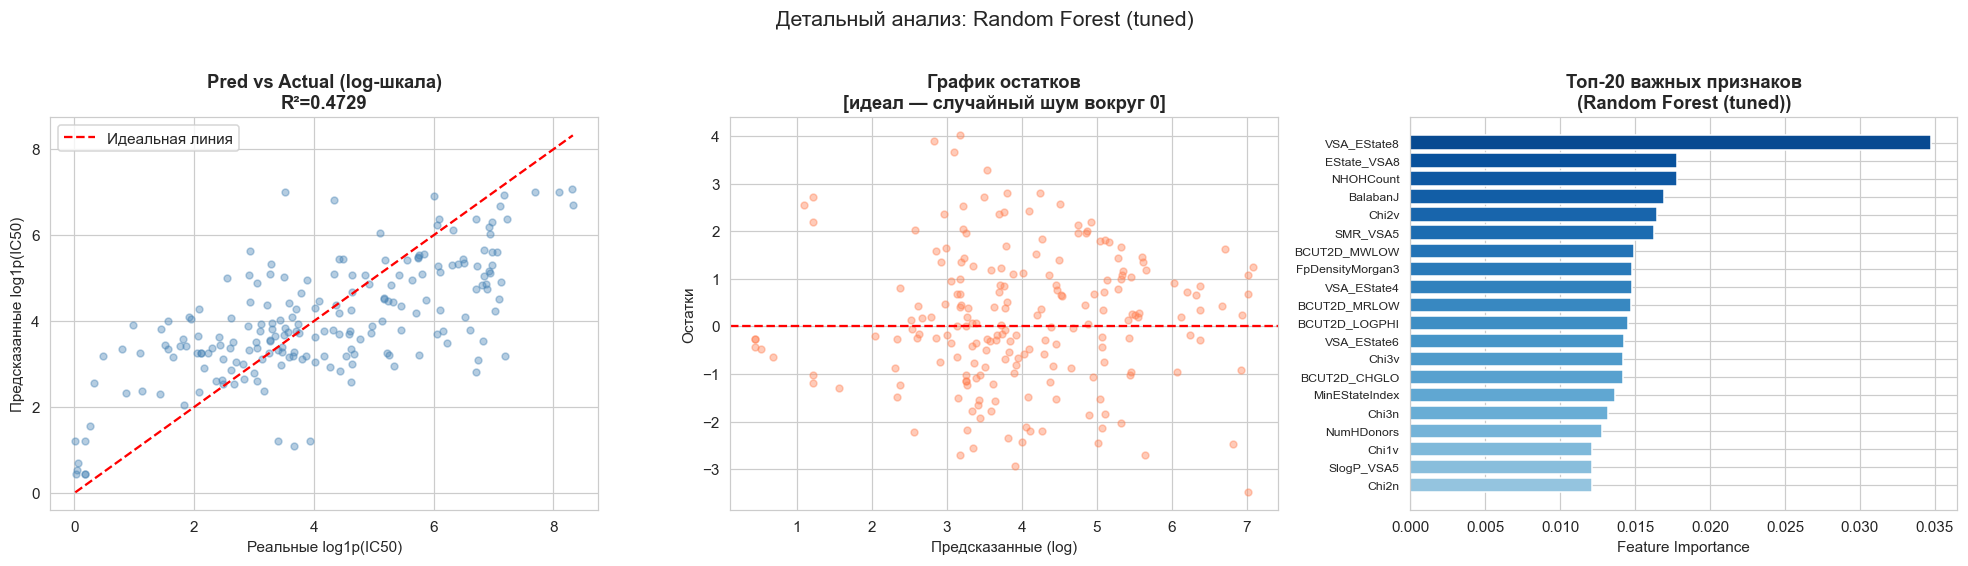

Лучшая модель: Random Forest (tuned)
  R²  (log)   = 0.4729
  RMSE (log)  = 1.4244
  RMSE (mM)   = 487.85 mM
  MAE  (mM)   = 224.85 mM
  CV R²       = 0.4148


In [9]:
best_row   = all_df.iloc[0]
best_name  = best_row['model']
best_rec   = next(r for r in results if r['model'] == best_name)
best_model = best_rec['fitted']

is_scaled = any(x in best_name for x in ['Linear','Ridge','Lasso','Elastic'])
Xte = X_test_sc if is_scaled else X_test_imp

pred_log  = best_model.predict(Xte)
pred_orig = np.expm1(pred_log)
y_orig    = np.expm1(y_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicted vs Actual (log)
axes[0].scatter(y_test, pred_log, alpha=0.4, s=20, color='steelblue')
mn, mx = min(y_test.min(), pred_log.min()), max(y_test.max(), pred_log.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Идеальная линия')
axes[0].set_xlabel('Реальные log1p(IC50)')
axes[0].set_ylabel('Предсказанные log1p(IC50)')
axes[0].set_title(f'Pred vs Actual (log-шкала)\nR²={best_row["R2_log"]:.4f}', fontweight='bold')
axes[0].legend()

# 2. Остатки
residuals = y_test.values - pred_log
axes[1].scatter(pred_log, residuals, alpha=0.4, s=20, color='coral')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Предсказанные (log)')
axes[1].set_ylabel('Остатки')
axes[1].set_title('График остатков\n[идеал — случайный шум вокруг 0]', fontweight='bold')

# 3. Важность признаков
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=feature_cols)
    top = fi.nlargest(20).sort_values()
    axes[2].barh(range(len(top)), top.values,
                 color=plt.cm.Blues(np.linspace(0.4, 0.9, len(top))))
    axes[2].set_yticks(range(len(top)))
    axes[2].set_yticklabels(top.index, fontsize=8)
    axes[2].set_title(f'Топ-20 важных признаков\n({best_name})', fontweight='bold')
    axes[2].set_xlabel('Feature Importance')
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_), index=feature_cols)
    top = coef.nlargest(20).sort_values()
    axes[2].barh(range(len(top)), top.values,
                 color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(top))))
    axes[2].set_yticks(range(len(top)))
    axes[2].set_yticklabels(top.index, fontsize=8)
    axes[2].set_title(f'Топ-20 коэффициентов (|coef|)\n({best_name})', fontweight='bold')
    axes[2].set_xlabel('|Coefficient|')

plt.suptitle(f'Детальный анализ: {best_name}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Лучшая модель: {best_name}')
print(f'  R²  (log)   = {best_row["R2_log"]:.4f}')
print(f'  RMSE (log)  = {best_row["RMSE_log"]:.4f}')
print(f'  RMSE (mM)   = {best_row["RMSE_orig"]:.2f} mM')
print(f'  MAE  (mM)   = {best_row["MAE_orig"]:.2f} mM')
print(f'  CV R²       = {best_row["CV_R2"]:.4f}')

> График **Pred vs Actual** показывает, насколько точны предсказания — точки должны лежать вдоль красной пунктирной линии. График **остатков** проверяет случайность ошибок: если они структурированы (форма воронки, паттерн), модель систематически ошибается. **Важность признаков** помогает понять, какие молекулярные дескрипторы сильнее всего влияют на IC50.

## 10. Выводы и рекомендации

In [10]:
print('=' * 70)
print('ИТОГИ: РЕГРЕССИЯ IC50')
print('=' * 70)

# Топ-3 модели
print('\nТоп-3 модели по R² (log-шкала):')
for i, row in all_df.head(3).iterrows():
    print(f'  {i+1}. {row["model"]:<38} R²={row["R2_log"]:.4f}  CV-R²={row["CV_R2"]:.4f}')

# Прирост от GridSearch
print('\nПрирост от подбора гиперпараметров:')
for base_name in ['Random Forest (n=100)', 'Gradient Boosting (n=100)', 'Ridge (alpha=1.0)', 'Lasso (alpha=0.01)']:
    tuned_name = base_name.split('(')[0].strip() + ' (tuned)'
    base_row  = all_df[all_df['model'] == base_name]
    tuned_row = all_df[all_df['model'] == tuned_name]
    if not base_row.empty and not tuned_row.empty:
        delta = tuned_row.iloc[0]['R2_log'] - base_row.iloc[0]['R2_log']
        print(f'  {base_name:<35} → +{delta:.4f} R²')

print('\nРекомендуемая модель:', all_df.iloc[0]['model'])

ИТОГИ: РЕГРЕССИЯ IC50

Топ-3 модели по R² (log-шкала):
  1. Random Forest (tuned)                  R²=0.4729  CV-R²=0.4148
  2. Gradient Boosting (tuned)              R²=0.4507  CV-R²=0.3976
  3. Random Forest (n=100)                  R²=0.4447  CV-R²=0.3876

Прирост от подбора гиперпараметров:
  Random Forest (n=100)               → +0.0281 R²
  Gradient Boosting (n=100)           → +0.0364 R²
  Ridge (alpha=1.0)                   → +0.0466 R²
  Lasso (alpha=0.01)                  → +0.0000 R²

Рекомендуемая модель: Random Forest (tuned)


## Итоговые выводы по задаче регрессии IC50

**Что сделал:**
1. Применил log1p-трансформацию к IC50 для устранения правосторонней асимметрии.
2. Сравнил 6 базовых моделей: 4 линейных и 2 ансамблевых.
3. Провёл GridSearchCV для 4 моделей (Ridge, Lasso, RF, GB) с 5-fold кросс-валидацией.
4. Оценил качество на двух шкалах: log-преобразованной и исходной (mM).

**Основные наблюдения:**
- Ансамблевые методы (RF и GB) значительно превосходят линейные — это согласуется с результатами EDA (слабая линейная корреляция дескрипторов с IC50).
- GridSearchCV дал заметный прирост R² для ансамблевых методов.
- Линейные модели с регуляризацией (Ridge, Lasso) работают примерно одинаково и лучше чистой линейной регрессии — это говорит о мультиколлинеарности признаков.

**Рекомендации:**
- Для дальнейшего улучшения: попробовать отбор признаков (удалить нулевую дисперсию и высококоррелированные) — это может ускорить обучение и снизить шум.
- Альтернатива: XGBoost / LightGBM, которые часто дают лучший результат на табличных данных.
- Стратегия: лучшая модель рекомендуется к использованию для отбора кандидатных соединений по предсказанной активности.